In [ ]:
#네이버 데이터랩 api 분석

In [2]:
import os
import sys
import urllib.request
import json
import pandas as pd

client_id = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
client_secret = "7MP3lY3dzz" # 이미지 속 Client Secret 입력
url = "https://openapi.naver.com/v1/datalab/search"

# 분석하고 싶은 키워드 설정
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-10",
    "timeUnit": "month", # 'date', 'week', 'month' 중 선택 가능
    "keywordGroups": [
        {
            "groupName": "가성비_건기식",
            "keywords": ["가성비건기식", "가성비영양제", "저가영양제", "저렴한영양제"]
        },
        {
            "groupName": "일반_영양제",
            "keywords": ["영양제추천", "종합비타민", "멀티비타민"]
        }
    ]
}

body = json.dumps(body, ensure_ascii=False)

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()

if(rescode==200):
    response_body = response.read()
    data = json.loads(response_body)
    
    # 데이터프레임 변환 로직
    results = data['results']
    df_list = []
    for res in results:
        temp_df = pd.DataFrame(res['data'])
        temp_df['group'] = res['title']
        df_list.append(temp_df)
    
    final_df = pd.concat(df_list)
    print("데이터 수집 완료!")
    print(final_df)
else:
    print("Error Code:" + rescode)

데이터 수집 완료!
        period      ratio    group
0   2024-01-01    0.00500  가성비_건기식
1   2024-02-01    0.01052  가성비_건기식
2   2024-03-01    0.01052  가성비_건기식
3   2024-04-01    0.01102  가성비_건기식
4   2024-05-01    0.00250  가성비_건기식
5   2024-07-01    0.00300  가성비_건기식
6   2024-08-01    0.00751  가성비_건기식
7   2024-09-01    0.00551  가성비_건기식
8   2024-10-01    0.00250  가성비_건기식
9   2024-11-01    0.00300  가성비_건기식
10  2024-12-01    0.00250  가성비_건기식
11  2025-01-01    0.01502  가성비_건기식
12  2025-02-01    0.01252  가성비_건기식
13  2025-03-01    0.01001  가성비_건기식
14  2025-04-01    0.00250  가성비_건기식
15  2025-05-01    0.00601  가성비_건기식
16  2025-08-01    0.00500  가성비_건기식
17  2025-09-01    0.00751  가성비_건기식
18  2025-10-01    0.00250  가성비_건기식
19  2025-11-01    0.00250  가성비_건기식
20  2026-02-01    0.00801  가성비_건기식
21  2026-03-01    0.00601  가성비_건기식
22  2026-04-01    0.01001  가성비_건기식
23  2026-05-01    0.00751  가성비_건기식
0   2024-01-01   81.26117   일반_영양제
1   2024-02-01   74.33456   일반_영양제
2   2024-03-01   79.76924   일반_영양제
3   2024-

     group      period     ratio
0   가성비영양제  2024-01-01   2.13675
1   가성비영양제  2024-02-01   3.41880
2   가성비영양제  2024-03-01   4.48717
3   가성비영양제  2024-04-01   4.70085
4   가성비영양제  2024-05-01   1.06837
..     ...         ...       ...
24  편의점영양제  2026-01-01  48.29059
25  편의점영양제  2026-02-01  43.37606
26  편의점영양제  2026-03-01  52.35042
27  편의점영양제  2026-04-01  58.76068
28  편의점영양제  2026-05-01  26.70940

[65 rows x 3 columns]


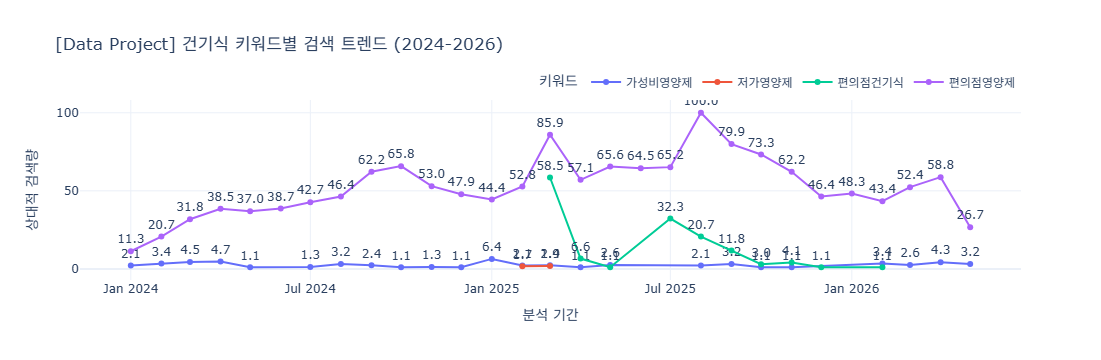

In [24]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
client_secret = "7MP3lY3dzz" 
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["가성비건기식", "가성비영양제", "저가영양제", "편의점건기식", "편의점영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups
}
body_json = json.dumps(body, ensure_ascii=False)

# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        final_df = pd.concat(df_list)
        print(final_df)
        
#7. 시각화 (fig.write_image 부분을 삭제했습니다!)
       # 7. 시각화 (Label 및 데이터 값 표시 강화)
        fig = px.line(final_df, x='period', y='ratio', color='group',
                      title='[Data Project] 건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={
                          'period': '분석 기간', 
                          'ratio': '상대적 검색량', 
                          'group': '키워드'
                      },
                      markers=True,
                      text="ratio", # 그래프 위에 수치 표시
                      template='plotly_white')

        # 텍스트 라벨 위치 및 포맷 설정
        fig.update_traces(
            textposition="top center", 
            texttemplate='%{text:.1f}' # 소수점 첫째자리까지만 표시
        )

        fig.update_layout(
            hovermode='x unified',
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
        )

        fig.show()

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

        period    ratio   group
0   2024-01-01  4.80629     건기식
1   2024-02-01  3.60472     건기식
2   2024-03-01  3.70734     건기식
3   2024-04-01  3.70307     건기식
4   2024-05-01  4.13067     건기식
..         ...      ...     ...
24  2026-01-01  5.32797  다이소영양제
25  2026-02-01  4.59249  다이소영양제
26  2026-03-01  5.31942  다이소영양제
27  2026-04-01  4.44710  다이소영양제
28  2026-05-01  1.93278  다이소영양제

[116 rows x 3 columns]


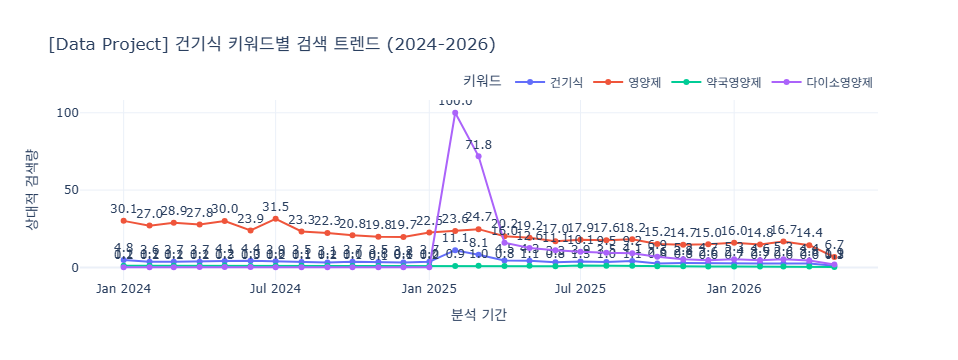

In [30]:
import os
import sys
import urllib.request
import json
import pandas as pd
import plotly.express as px

# 1. 인증 정보 설정 (이미지에서 확인하신 본인 정보를 넣으세요)
client_id = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
client_secret = "7MP3lY3dzz" 
url = "https://openapi.naver.com/v1/datalab/search"

# 2. 분석 키워드 설정
target_keywords = ["건기식", "영양제", "고가영양제", "약국영양제", "다이소영양제"]

# 3. 키워드별 개별 그룹 자동 생성
keyword_groups = []
for kw in target_keywords:
    keyword_groups.append({
        "groupName": kw, 
        "keywords": [kw] 
    })

# 4. API 요청 본문 작성
body = {
    "startDate": "2024-01-01",
    "endDate": "2026-05-14",
    "timeUnit": "month",
    "keywordGroups": keyword_groups,

       # --- 여기서 필터링 조건을 추가합니다 ---
    "ages": ["3", "4", "5", "6"], # 20대~30대 필터링
    "gender": "m",                 # 비워두면 전체, 'f'는 여성, 'm'은 남성
    "device": ""                  # pc / mo 선택 가능
}


body_json = json.dumps(body, ensure_ascii=False)



# 5. API 호출 실행
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id", client_id)
request.add_header("X-Naver-Client-Secret", client_secret)
request.add_header("Content-Type", "application/json")

try:
    response = urllib.request.urlopen(request, data=body_json.encode("utf-8"))
    rescode = response.getcode()
    
    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body)
        
        # 6. 데이터프레임 변환
        df_list = []
        for res in data['results']:
            temp_df = pd.DataFrame(res['data'])
            temp_df['group'] = res['title']
            df_list.append(temp_df)
        
        final_df = pd.concat(df_list)
        print(final_df)
        
#7. 시각화 (fig.write_image 부분을 삭제했습니다!)
       # 7. 시각화 (Label 및 데이터 값 표시 강화)
        fig = px.line(final_df, x='period', y='ratio', color='group',
                      title='[Data Project] 건기식 키워드별 검색 트렌드 (2024-2026)',
                      labels={
                          'period': '분석 기간', 
                          'ratio': '상대적 검색량', 
                          'group': '키워드'
                      },
                      markers=True,
                      text="ratio", # 그래프 위에 수치 표시
                      template='plotly_white')

        # 텍스트 라벨 위치 및 포맷 설정
        fig.update_traces(
            textposition="top center", 
            texttemplate='%{text:.1f}' # 소수점 첫째자리까지만 표시
        )

        fig.update_layout(
            hovermode='x unified',
            legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
        )

        fig.show()

    else:
        print(f"Error: API 요청 실패 (Code: {rescode})")

except Exception as e:
    print(f"Error 발생: {e}")

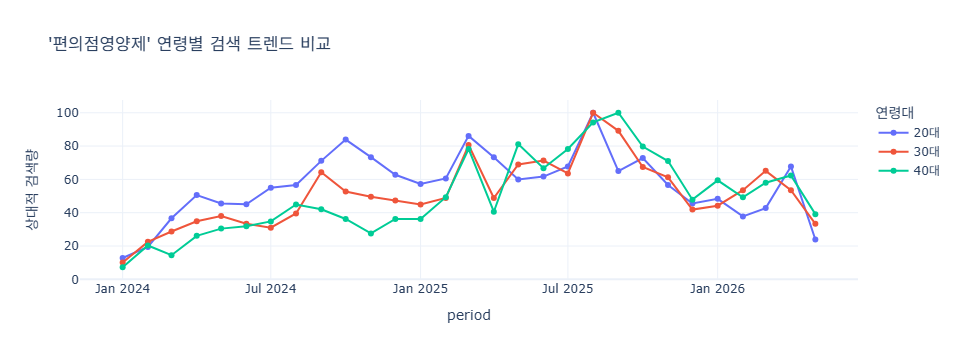

In [35]:
import urllib.request
import json
import pandas as pd
import plotly.express as px

client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz" 
url = "https://openapi.naver.com/v1/datalab/search"

# 1. 분석 설정
target_kw = "편의점영양제" # 가장 핵심인 키워드 하나를 기준으로 연령 비교
age_dict = {'20대': ['3', '4'], '30대': ['5', '6'], '40대': ['7', '8']}
all_data = []

# 2. 연령별 루프 실행 (연령별로 API를 따로 호출하여 수집)
for age_name, age_codes in age_dict.items():
    body = {
        "startDate": "2024-01-01",
        "endDate": "2026-05-14",
        "timeUnit": "month",
        "keywordGroups": [{"groupName": target_kw, "keywords": [target_kw]}],
        "ages": age_codes
    }
    
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)
    request.add_header("Content-Type", "application/json")
    
    response = urllib.request.urlopen(request, data=json.dumps(body).encode("utf-8"))
    res_data = json.loads(response.read())
    
    # 데이터 정리
    for item in res_data['results'][0]['data']:
        all_data.append({
            'period': item['period'],
            'ratio': item['ratio'],
            'age_group': age_name
        })

# 3. 데이터프레임 통합
df_age = pd.DataFrame(all_data)

# 4. 시각화 (연령별 비교)
fig = px.line(df_age, x='period', y='ratio', color='age_group',
              title=f"'{target_kw}' 연령별 검색 트렌드 비교",
              labels={'ratio': '상대적 검색량', 'age_group': '연령대'},
              markers=True, template='plotly_white')

fig.show()

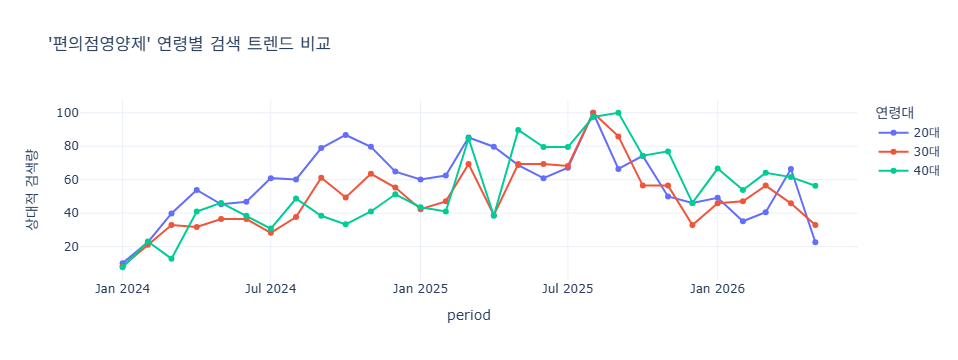

In [37]:
import urllib.request
import json
import pandas as pd
import plotly.express as px

client_id = "iQYuA4jIAZWE78ZCH4p9" 
client_secret = "7MP3lY3dzz" 
url = "https://openapi.naver.com/v1/datalab/search"

# 1. 분석 설정
target_kw = "편의점영양제" # 가장 핵심인 키워드 하나를 기준으로 연령 비교
age_dict = {'20대': ['3', '4'], '30대': ['5', '6'], '40대': ['7', '8']}
all_data = []

# 2. 연령별 루프 실행 (연령별로 API를 따로 호출하여 수집)
for age_name, age_codes in age_dict.items():
    body = {
        "startDate": "2024-01-01",
        "endDate": "2026-05-14",
        "timeUnit": "month",
        "keywordGroups": [{"groupName": target_kw, "keywords": [target_kw]}],
        "ages": age_codes,
         "gender": "f"
    }
    
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)
    request.add_header("Content-Type", "application/json")
    
    response = urllib.request.urlopen(request, data=json.dumps(body).encode("utf-8"))
    res_data = json.loads(response.read())
    
    # 데이터 정리
    for item in res_data['results'][0]['data']:
        all_data.append({
            'period': item['period'],
            'ratio': item['ratio'],
            'age_group': age_name
        })

# 3. 데이터프레임 통합
df_age = pd.DataFrame(all_data)

# 4. 시각화 (연령별 비교)
fig = px.line(df_age, x='period', y='ratio', color='age_group',
              title=f"'{target_kw}' 연령별 검색 트렌드 비교",
              labels={'ratio': '상대적 검색량', 'age_group': '연령대'},
              markers=True, template='plotly_white')

fig.show()

In [ ]:
##검색 API 분석

In [ ]:
import time
import hashlib
import hmac
import base64
import requests
import pandas as pd

# -----------------------------------------------------------
# [설정 단계] 네이버 광고 시스템에서 확인한 인증 정보를 입력하세요.
# -----------------------------------------------------------
CUSTOMER_ID = "YOUR_CUSTOMER_ID"       # 광고 계정 고유 번호
ACCESS_LICENSE = "YOUR_ACCESS_LICENSE" # API 액세스 라이선스
SECRET_KEY = "YOUR_SECRET_KEY"         # 보안을 위한 비밀키

# -----------------------------------------------------------
# [함수 정의] 네이버 광고 API 전용 인증 헤더 생성기
# 네이버 광고 API는 보안을 위해 요청 시점마다 '전자서명'을 요구합니다.
# -----------------------------------------------------------
def get_header(method, uri, api_key, secret_key, customer_id):
    # 1. 현재 시간을 밀리초 단위로 생성 (요청 유효성 검사용)
    timestamp = str(round(time.time() * 1000))
    
    # 2. 메시지 조립: 시간 + HTTP메서드(GET) + 호출주소(URI)
    message = f"{timestamp}.{method}.{uri}"
    
    # 3. HMAC-SHA256 알고리즘으로 암호화 서명 생성
    signature = hmac.new(
        secret_key.encode(), 
        message.encode(), 
        hashlib.sha256
    ).digest()
    
    # 4. 최종적으로 API 호출에 필요한 4가지 필수 헤더 반환
    return {
        "Content-Type": "application/json; charset=UTF-8",
        "X-Timestamp": timestamp,
        "X-API-KEY": api_key,
        "X-Customer": str(customer_id),
        "X-Signature": base64.b64encode(signature).decode() # 서명을 Base64로 인코딩
    }

# -----------------------------------------------------------
# [실행 단계] 키워드 조회 및 데이터 가공
# -----------------------------------------------------------
BASE_URL = "https://api.naver.com"
uri = "/keywordstool" # 키워드 도구 서비스 주소
method = "GET"

# 분석하고 싶은 키워드 리스트 (최대 5개 추천)
target_keywords = ["가성비영양제", "가성비건기식", "저가영양제", "영양제추천", "멀티비타민"]

# API에 전달할 파라미터 (hintKeywords: 조회할 키워드, showDetail: 상세정보 포함 여부)
params = {"hintKeywords": target_keywords, "showDetail": "1"}

# API 호출
response = requests.get(
    BASE_URL + uri, 
    params=params, 
    headers=get_header(method, uri, ACCESS_LICENSE, SECRET_KEY, CUSTOMER_ID)
)

# 데이터 정리 및 출력
if response.status_code == 200:
    data = response.json()['keywordList']
    df_vol = pd.DataFrame(data)
    
    # 네이버는 PC와 모바일 조회수를 따로 줍니다. 이를 합산하여 '전체 조회수' 생성
    # '< 10'으로 표시되는 저조한 키워드는 0이나 5로 치환하여 수치화할 수 있습니다.
    df_vol['monthlyPcQcCnt'] = pd.to_numeric(df_vol['monthlyPcQcCnt'], errors='coerce').fillna(5)
    df_vol['monthlyMobileQcCnt'] = pd.to_numeric(df_vol['monthlyMobileQcCnt'], errors='coerce').fillna(5)
    
    df_vol['total_search_volume'] = df_vol['monthlyPcQcCnt'] + df_vol['monthlyMobileQcCnt']
    
    # 결과 요약 (가독성을 위해 핵심 컬럼만 추출)
    result = df_vol[['relKeyword', 'monthlyPcQcCnt', 'monthlyMobileQcCnt', 'total_search_volume']]
    result.columns = ['키워드', 'PC검색량', '모바일검색량', '총조회수(30일)']
    
    print("--- 최근 30일간 실측 검색량 데이터 ---")
    print(result)
else:
    print(f"API 호출 실패! 에러코드: {response.status_code}")
    print(response.text)